# 06 · Do the pasted maps reproduce the theory Cls?

The load-bearing null test. A pasted map at the fiducial point is measured through the same
estimator and compared band-by-band with the theory prediction for the same inputs, at the
production resolution (nside 1024, ell to 2048). Any residual here propagates directly into
the mock-SBI posterior.

`compare_three_probe_nside1024_ell2048.py` · `compare_three_probe_noiseless_cls.py` ·
`validate_mock_sbi_paste_nulls.py` · `plot_mock_sbi_training_spread.py`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

In [2]:
P = VAL / "noiseless_cls_gate3_nside1024/ell2048/nside1024_ell2048_paste_vs_projected_theory.h5"
with h5py.File(P, "r") as h:
    ell = np.asarray(h["ell_effective"], float)
    prod = {s: {k: np.asarray(h[f"{s}/{k}"], float) for k in h[s]} for s in
            ("gg", "gy", "gkappa", "gtau")}
    prov = json.loads(str(h.attrs["provenance_json"]))
print("bands:", len(ell), " ell_eff:", ell.round(0))
print("band policy:", prov.get("band_policy", "(n/a)"))

bands: 15  ell_eff: [  90.  114.  143.  180.  226.  286.  360.  453.  570.  718.  904. 1138.
 1432. 1803. 2029.]
band policy: native integer bands through 2009 plus partial [2010,2049)


### Pasted map against theory, and the fractional residual

gg       |residual| median 10.21%   max  17.61%  at ell 180
gy       |residual| median 12.79%   max  30.83%  at ell 180
gkappa   |residual| median 10.93%   max  22.61%  at ell 180
gtau     |residual| median 10.70%   max  22.61%  at ell 180



shaded band = +/-5%


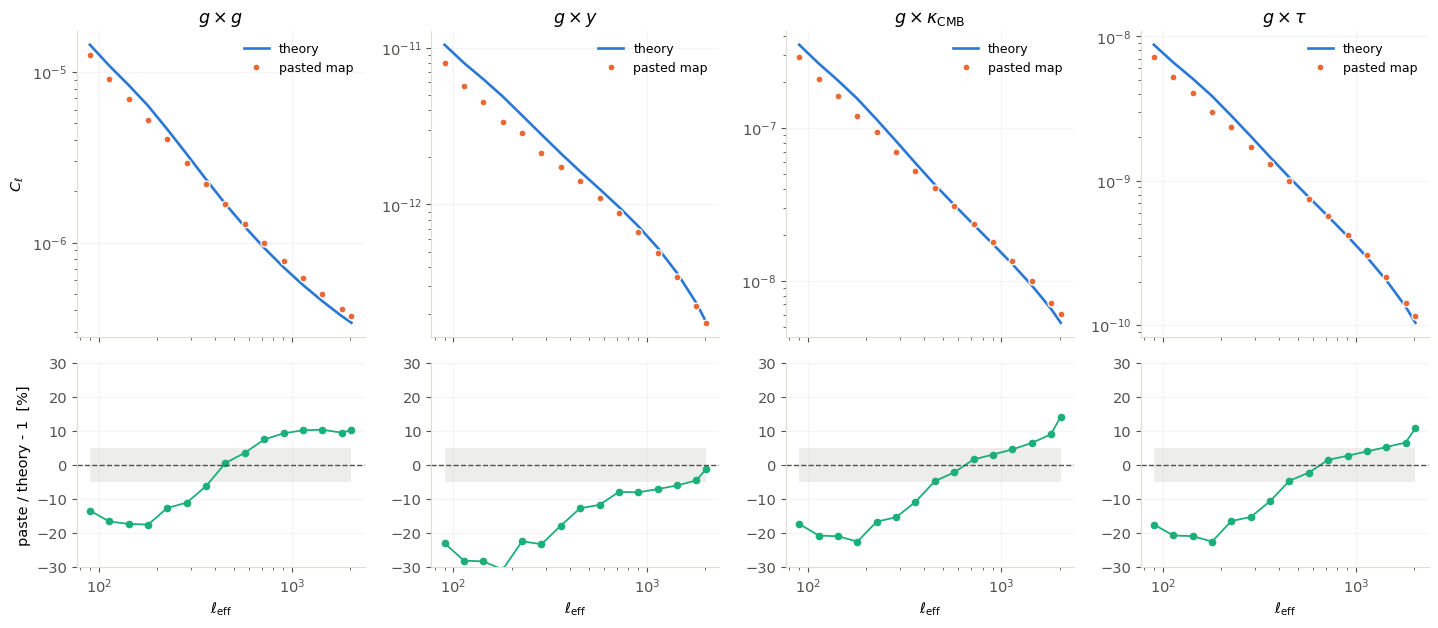

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14.5, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [1.5, 1]})
for k, s in enumerate(("gg", "gy", "gkappa", "gtau")):
    t, b = axes[0, k], axes[1, k]
    m, th = prod[s]["mock_decoupled_total"], prod[s]["theory_decoupled_total"]
    t.loglog(ell, np.abs(th), color=BLUE, lw=1.9, label="theory")
    t.loglog(ell, np.abs(m), "o", ms=5, color=ORANGE, mec="white", mew=.9, label="pasted map")
    t.set_title(LBL[s]); t.grid(alpha=.3, color=GRID); t.legend(frameon=False, fontsize=9)
    r = prod[s]["fractional_residual"]
    b.plot(ell, 100 * r, "o-", ms=4.5, color=GREEN, lw=1.3)
    b.axhline(0, color=INK2, lw=1.0, ls="--")
    b.fill_between(ell, -5, 5, color=INK2, alpha=.10, lw=0)
    b.set_xscale("log"); b.set_xlabel(r"$\ell_{\rm eff}$"); b.grid(alpha=.3, color=GRID)
    b.set_ylim(-30, 30)
    print(f"{s:<8} |residual| median {100*np.median(np.abs(r)):5.2f}%   "
          f"max {100*np.max(np.abs(r)):6.2f}%  at ell {ell[np.argmax(np.abs(r))]:.0f}")
axes[0, 0].set_ylabel(r"$C_\ell$"); axes[1, 0].set_ylabel("paste / theory - 1  [%]")
fig.tight_layout()
print("\nshaded band = +/-5%")

The 1-halo dominated high-ell bands are where the paste and the analytic theory disagree
most — the paste paints a discrete halo realisation, the theory integrates a smooth mass
function. This is a real limitation of the comparison, not a bug, and it is the reason the
mock-SBI posterior is trained on the paste rather than corrected towards theory.

### Signal spread against noise spread in the training set

above 1 = the design moves the model further than the noise; that band informs theta


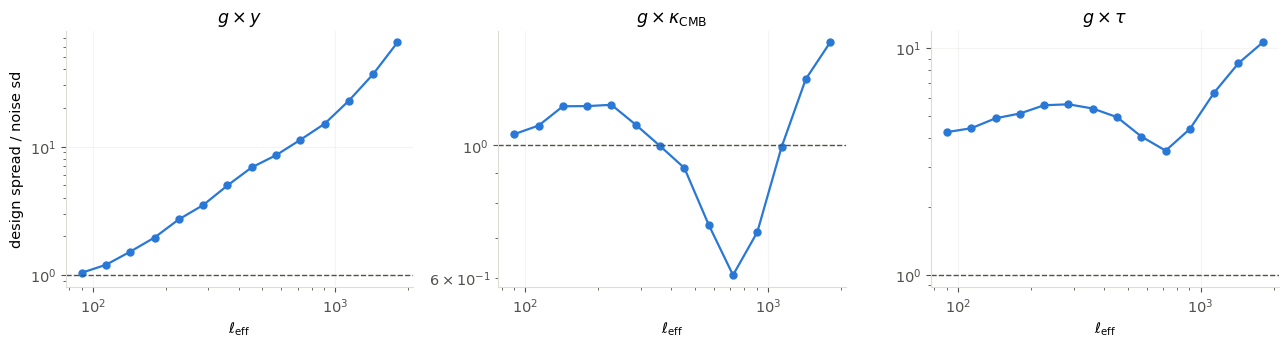

In [4]:
tr = np.load(MSBI / "trial/training_set_n0038.npz", allow_pickle=True)
x, mu = np.asarray(tr["x"], float), np.asarray(tr["mu"], float)
with h5py.File(INF / "observation_mock.h5", "r") as h:
    truth = np.asarray(h["data_vector"], float)
import mock_sbi_common as msc
ctx = msc.load_estimator_context()
ell2, sd = np.asarray(ctx.effective_ell, float), np.sqrt(np.diag(np.asarray(ctx.covariance, float)))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for k, (ax, s) in enumerate(zip(axes, SPECTRA)):
    sl = slice(14*k, 14*(k+1))
    ax.semilogx(ell2, mu[:, sl].std(0, ddof=1) / sd[sl], "o-", color=BLUE, lw=1.6, ms=5)
    ax.axhline(1.0, color=INK2, lw=1.0, ls="--")
    ax.set_yscale("log"); ax.set_title(LBL[s]); ax.set_xlabel(r"$\ell_{\rm eff}$")
    ax.grid(alpha=.3, color=GRID)
axes[0].set_ylabel("design spread / noise sd")
fig.tight_layout()
print("above 1 = the design moves the model further than the noise; that band informs theta")